In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array, load_img

In [ ]:
path = './Dataset'
label_list = []
for dir in os.listdir(path):
    label_list.append(dir)

images = []
classes = []

for i, label in enumerate(label_list):
    full_path = os.path.join(path, label)
    for j, image in enumerate(os.listdir(full_path)):
        img_path = os.path.join(full_path, image)
        img = load_img(img_path)
        img = img_to_array(img)
        img = tf.image.rgb_to_grayscale(img)
        img = img / 255

        images.append(img)
        classes.append(i)

In [3]:
y = tf.keras.utils.to_categorical(classes, len(label_list))
images = np.asarray(images)

In [4]:
x_train, x_temp, y_train, y_temp = train_test_split(images, y, train_size=0.8, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, train_size=0.5, random_state=42)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same', input_shape=(224, 224, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

c:\Github\deep-learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, callbacks=early_stopping)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.4806 - loss: 1.0916 - val_accuracy: 0.7550 - val_loss: 0.7078
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8169 - loss: 0.5132 - val_accuracy: 0.7950 - val_loss: 0.5229
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8931 - loss: 0.3088 - val_accuracy: 0.8500 - val_loss: 0.4238
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9444 - loss: 0.1599 - val_accuracy: 0.8150 - val_loss: 0.4524
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9631 - loss: 0.0957 - val_accuracy: 0.8500 - val_loss: 0.4306
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9806 - loss: 0.0604 - val_accuracy: 0.8550 - val_loss: 0.4787


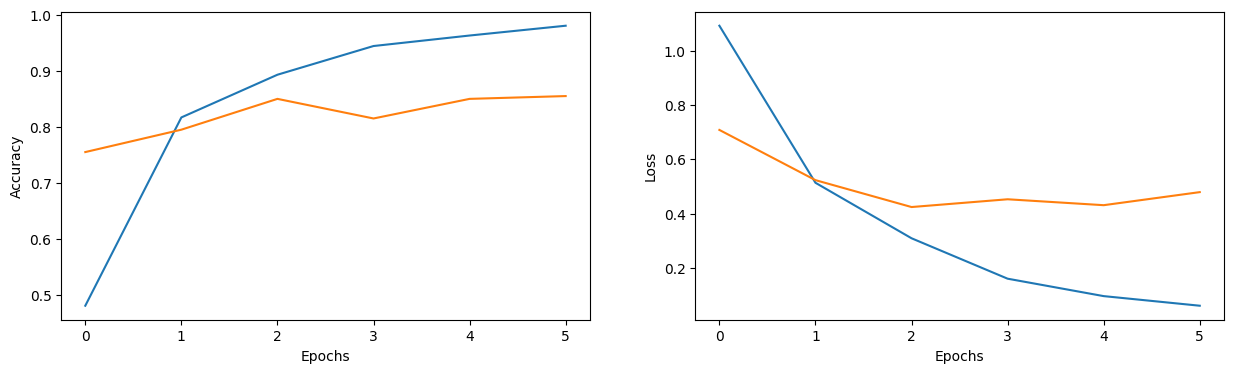

In [10]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

In [11]:
loss, acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Acc: {acc}, Loss: {loss}')

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true=y_true, y_pred=y_pred, target_names=label_list))

7/7 - 0s - 18ms/step - accuracy: 0.9100 - loss: 0.2648
Acc: 0.9100000262260437, Loss: 0.26479431986808777
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

    Broccoli       0.94      0.91      0.92        54
      Carrot       0.94      0.94      0.94        53
    Cucumber       0.90      0.88      0.89        41
      Tomato       0.85      0.90      0.88        52

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

